In [1]:
import torch
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()

        logits = self.model(x)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        score = logits[:, class_idx]
        score.backward(retain_graph=True)

        # Grad-CAM
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam, class_idx

In [2]:
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.eval().to(device)

target_layer = model.layer4[-1]  # conv cuối của ResNet
gradcam = GradCAM(model, target_layer)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/thuannd/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100.0%


In [3]:
import cv2
import numpy as np
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img = cv2.imread("../images/image.png")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_tensor = transform(img_rgb).unsqueeze(0).to(device)

In [4]:
cam, class_idx = gradcam(input_tensor)

cam = cam.squeeze().cpu().numpy()
cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

/home/thuannd/miniconda3/envs/cs2230/lib/python3.13/site-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


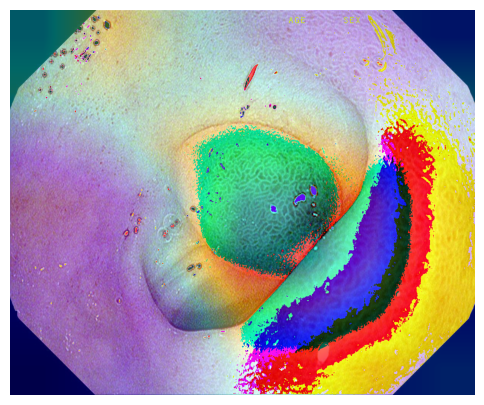

In [5]:
import matplotlib.pyplot as plt

heatmap = cv2.applyColorMap(
    np.uint8(255 * cam),
    cv2.COLORMAP_JET
)

overlay = heatmap * 0.4 + img

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay.astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()